In [5]:
from typing import Dict, TypedDict, List
from langgraph.graph import StateGraph, START, END
import random

In [4]:
class AgentState(TypedDict):
    name: str
    number: List[int]
    counter: int


In [7]:
def greeter(state: AgentState) -> AgentState:
    """This function greets the user and initializes the counter."""

    state['name'] = f"Hello, {state['name']}!"
    state['counter'] = 0
    return state


def random_node(state: AgentState) -> AgentState:
    """This function generates a random number and appends it to the list."""
    
    state['number'].append(random.randint(0, 10))
    state['counter'] += 1
    return state

# looping logic
def should_continue(state: AgentState) -> AgentState:
    """This function checks if the counter is less than 5."""
    
    if state['counter'] < 5:
        print(f"Counter is {state['counter']}, continuing...")
        return "loop" # continue the loop | loop edge
    else:
        return "exit" # exit the loop | exit edge

In [10]:
graph = StateGraph(AgentState)

graph.add_node("random_node", random_node)  # add the router node to the graph
graph.add_node("greeting_node", greeter)  # add the greeter node to the graph

graph.add_edge(START, "greeting_node")  # add an edge from START to the greeter node
graph.add_edge("greeting_node", "random_node")  # add an edge from the
graph.add_conditional_edges(
    "random_node",
    should_continue,
    {
        "loop": "random_node",  # if the condition is true, go back to the router node
        "exit": END,  # if the condition is false, go to the END node
    }
)

app = graph.compile()  # compile the graph into an executable application

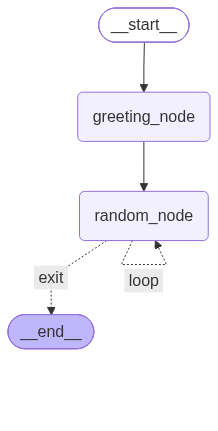

In [11]:
from IPython.display import Image, display
display(Image(app.get_graph().draw_mermaid_png()))  # display the graph as an image in the notebook

In [12]:
input = AgentState(name="Matty", number=[], counter=0)  # create an initial state for the graph
ans = app.invoke(input)  # invoke the graph with the initial state

Counter is 1, continuing...
Counter is 2, continuing...
Counter is 3, continuing...
Counter is 4, continuing...


In [13]:
ans

{'name': 'Hello, Matty!', 'number': [2, 7, 6, 2, 9], 'counter': 5}